In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib qt

custom_params = {
    'font.family': 'serif',
}

plt.rcParams.update(custom_params)

# **Probabilidad de llegada de una $mCP$ con distintas energías**

Primero suponemos que la millicharge se genera en la atmósfera y que en este proceso pierde energía tanto en la atmósfera como en la tierra que tiene que atravesar la partícula hasta que llega al detector, en este caso **SENSEI** que está a 2000 m de profundidad

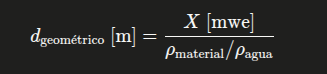

In [3]:
def D_overburden(d,theta):
    '''
    Calculates the overburden distance D for a given depth d and zenith angle theta.
    d: depth in meters (of the experiment)
    theta: zenith angle in radians
    '''
    R_t = 6.378e6 # [m] Radio de la tierra
    D = np.sqrt((R_t-d)**2*np.cos(theta)**2+d*(2*R_t-d))-(R_t-d)*np.cos(theta)
    return D

def R_average(eps, Ei, Ef, a=None, b=None):
    '''
    Calculates the average distance R that a mCP travels in the earth 
        eps: mCP charge fraction (e.g., 1e-3 for a mCP with charge 0.001e)
        Ei: initial energy of the mCP in the surface(in GeV)
        Ef: final energy of the mCP in the surface(in GeV)
        returns: R in meters using the formula R = (1/eps^2)*(1/b)*log((1+(a/b)*Ei)/(1+(a/b)*Ef))*(1/2.65)

    b is in 1/mwe units, so we may need to convert it to 1/m since D is 
    in meters. The paper says that this value was calculated for a "standard
    rock shielding so we consider 1 mwe = (1/2.65) m of rock "
    '''

    if a is None:
        a = 0.223 # [GeV/mwe]
    if b is None:
        b = 4.64e-4 # [1/mwe]

    R = (1/(eps**2*b))*np.log((1+(b/a)*Ei)/(1+(b/a)*Ef)) # [mwe]
    R_m = R*(1/2.65) # Convert R from mwe to m
    return R_m

def P_arrival(eps, Ei, Ef, d, theta):
    '''
    Calculates the probability of arrival of a mCP at the detector given its charge fraction, initial and final energy, depth of the experiment, and zenith angle.
    eps: mCP charge fraction
    Ei: initial energy of the mCP in GeV
    Ef: final energy of the mCP in GeV
    d: depth of the experiment in meters
    theta: zenith angle in radians
    returns: probability of arrival at the detector
    '''
    D = D_overburden(d, theta) # Calculate overburden distance D
    R = R_average(eps, Ei, Ef) # Calculate average distance R that the mCP travels in the earth
    P = np.exp(-D/R) # Probability of arrival using the formula P = exp(-D/R)
    return P

In [4]:
Ef = 1 # GeV
Ei = np.array([5,14.6,42.5,124.0,361.7])
eps2 = np.array([1e-4,1e-2])
theta = np.linspace(-np.pi, 0, 1000) 
P_E0 = np.zeros((len(Ei), len(theta)))
P_E1 = np.zeros((len(Ei), len(theta)))
d = 1500/2.65 # Depth of the experiment in meters
for i in range(len(Ei)):
    P_0 = P_arrival(np.sqrt(eps2[0]), Ei[i], Ef, d, theta)
    P_1 = P_arrival(np.sqrt(eps2[1]), Ei[i], Ef, d, theta)
    P_E0[i,:] = P_0
    P_E1[i,:] = P_1


In [5]:
plt.close('all')
colors = ['blue', 'orange', 'green', 'red', 'purple']
plt.figure(figsize=(10, 6))
for i in range(len(Ei)):
    
    plt.plot(np.cos(theta), P_E0[i,:], label=f'$\epsilon ² = 10^{{-4}}$, $E_i =${Ei[i]} GeV',color = colors[i],linestyle='--')
    plt.plot(np.cos(theta), P_E1[i,:], label=f'$\epsilon ² = 10^{{-2}}$, $E_i =${Ei[i]} GeV', color = colors[i])
    plt.xlabel(f'$cos(\\theta)$')
    plt.ylabel('Probability to arrive with $E_f = 1$ GeV')
    plt.legend()
plt.grid(linestyle='--')

<>:6: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:7: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:6: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:7: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
/tmp/ipykernel_31491/3175871264.py:6: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  plt.plot(np.cos(theta), P_E0[i,:], label=f'$\epsilon ² = 10^{{-4}}$, $E_i =${Ei[i]} GeV',color = colors[i],linestyle='--')
/tmp/ipykernel_31491/3175871264.py:7: SyntaxWarning: "\e" is an invalid escape

# Algunos gráficos


In [6]:
PB = pd.read_csv('/home/lurishi/Escritorio/Doctorado/Mcp_gráficos_papers/Flujo_PB.csv',sep=';')
MD = pd.read_csv('/home/lurishi/Escritorio/Doctorado/Mcp_gráficos_papers/Flujo_MD_tot.csv',sep=';')

In [7]:
PB.columns, MD.columns

(Index(['MmCP', 'Flujo_Total'], dtype='str'),
 Index(['MmCP', 'Flujo_Total'], dtype='str'))

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(PB['MmCP'], PB['Flujo_Total'], label='PB', color='blue')
plt.plot(MD['MmCP'], MD['Flujo_Total'], label='MD', color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e1, 1.5e3)
plt.xlabel(f'Mass m$_{{\chi}}$ (MeV/c$^{{2}}$)')
plt.ylabel(f'Total Flux $\Phi$ (cm$^{{-2}}$ s$^{{-1}}$sr$^{{-1}}$)')
plt.title('Flux vs Mass')
plt.legend()
plt.show()
plt.savefig('Figuras/flux_vs_mass.pdf', dpi=300)
plt.savefig('Figuras/flux_vs_mass.png', dpi=300)

<>:7: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:8: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:7: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:8: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
/tmp/ipykernel_31491/805597849.py:7: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  plt.xlabel(f'Mass m$_{{\chi}}$ (MeV/c$^{{2}}$)')
/tmp/ipykernel_31491/805597849.py:8: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A

qt.qpa.wayland.textinput: virtual void QtWaylandClient::QWaylandTextInputv3::zwp_text_input_v3_leave(wl_surface*) Got leave event for surface 0x0 with focusing surface 0x64a66e3225d0
